In [1]:
import pandas as pd #IMPORTAR LIBRERIA PANDAS, CUANDO ESCRIBA pd INVOCA LA LIBRERIA PANDAS

In [2]:
from google.colab import drive  #Ingresando al drive.
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os #importando el modulo os.

In [4]:
os.getcwd()

'/content'

In [5]:
path = '/content/drive/MyDrive/CIENCIA_DE_DATOS' #Ubicamos MyDrive

In [6]:
os.chdir(path)

In [13]:
clientes = pd.read_csv('customers.csv') #TRAEMOS BASE DE DATOS

In [14]:
clientes.info() #Consultar las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Age              2000 non-null   int64 
 2   Education        2000 non-null   object
 3   Income           2000 non-null   int64 
 4   Occupation       2000 non-null   object
 5   Gender           2000 non-null   object
 6   Marital Status   2000 non-null   object
 7   Settlement Size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


# Analisis de clientes

|Variable|Tipo de variable |Descripcion|
|---|---|---|
|CustomerID|int|Numero de identificacion de una persona (no se repite)|
|Age|int|Edad de cada persona(se puede reptir)|
|Education|Categórica|Nivel de estudios de cada persona|
|Income|int|Ingresos de cada persona|
|Occupation|Categórica|Ocupación de cada persona|
|Gender|Categórica|Genero de cada persona|
|Marital Status|Categórica|Estado Civil de cada persona|
|Settlement Size|Categórica|Tamaño del poblado|

In [56]:
# --- 1. CÁLCULOS PARA EDAD (Age) ---
media_edad = clientes["Age"].mean()
mediana_edad = clientes["Age"].median()
q1_edad = clientes["Age"].quantile(0.25)
q3_edad = clientes["Age"].quantile(0.75)
iqr_edad = q3_edad - q1_edad
limite_sup_edad = q3_edad + 1.5 * iqr_edad

# --- 2. CÁLCULOS PARA INGRESOS (Income) ---
media_ingresos = clientes["Income"].mean()
mediana_ingresos = clientes["Income"].median()
q1_ingresos = clientes["Income"].quantile(0.25)
q3_ingresos = clientes["Income"].quantile(0.75)
iqr_ingresos = q3_ingresos - q1_ingresos
limite_sup_ingresos = q3_ingresos + 1.5 * iqr_ingresos

# --- 3. REPORTE FINAL ---
print("--- RADIOGRAFÍA DEL PERFIL DEL CLIENTE ---")

print(f"\nANÁLISIS DE EDAD (Age):")
print(f"* El promedio de edad es: {media_edad:.1f} años.")
print(f"* La mitad de los clientes (mediana) tienen menos de: {mediana_edad:.0f} años.")
print(f"* El 50% central de los clientes está entre {q1_edad:.0f} y {q3_edad:.0f} años.")

print(f"\nANÁLISIS DE INGRESOS (Income):")
print(f"* El ingreso promedio es: ${media_ingresos:,.2f} USD.")
print(f"* El ingreso mediano es: ${mediana_ingresos:,.2f} USD.") # Corregido: agregamos la mediana
print(f"* Alerta Outliers: Ingresos mayores a ${limite_sup_ingresos:,.2f} son atípicos.")

--- RADIOGRAFÍA DEL PERFIL DEL CLIENTE ---

ANÁLISIS DE EDAD (Age):
* El promedio de edad es: 35.9 años.
* La mitad de los clientes (mediana) tienen menos de: 33 años.
* El 50% central de los clientes está entre 27 y 42 años.

ANÁLISIS DE INGRESOS (Income):
* El ingreso promedio es: $120,954.42 USD.
* El ingreso mediano es: $115,548.50 USD.
* Alerta Outliers: Ingresos mayores a $198,685.75 son atípicos.


--- ANÁLISIS DE INGRESOS DE CLIENTES ---
Media (Promedio Matemático): $120,954.42 USD
Mediana (El CLIENTE del medio): $115,548.50 USD


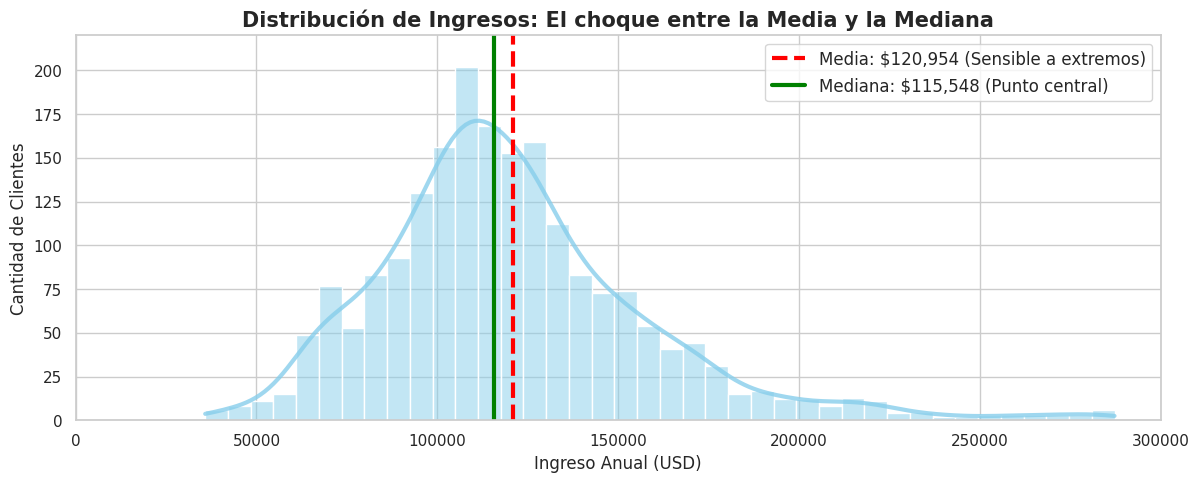

In [54]:
# #1. Cálculos matemáticos de tendencia central
# Calculamos el promedio: la suma de todos los sueldos dividida por el total de clientes
media_ingresos = clientes["Income"].mean()
# Calculamos el punto medio: si ordenamos a todos de menor a mayor, este es el que queda justo en el centro
mediana_ingresos = clientes["Income"].median()

# Reporte en consola con formato de moneda (usando :,.2f para miles y decimales)
print("--- ANÁLISIS DE INGRESOS DE CLIENTES ---")
print(f"Media (Promedio Matemático): ${media_ingresos:,.2f} USD")
print(f"Mediana (El CLIENTE del medio): ${mediana_ingresos:,.2f} USD")

# #2. Configuración de la Visualización
plt.figure(figsize=(14, 5))

# Filtro visual: Excluimos valores extremadamente altos (outliers) solo para que el gráfico no se vea comprimido
datos_visuales = clientes[clientes["Income"] < 305000]

# Histograma con curva de densidad (KDE)
# 'bins=40' para tener más detalle en las barras
sns.histplot(datos_visuales["Income"], bins=40, color="skyblue", kde=True,
             line_kws={"linewidth": 3, "color": "navy", "alpha": 0.8})

# Línea Roja (Media): Suele estar a la derecha en datos de ingresos por el efecto de los salarios altos
plt.axvline(media_ingresos, color="red", linestyle="dashed", linewidth=3,
            label=f"Media: ${media_ingresos:,.0f} (Sensible a extremos)")

# Línea Verde (Mediana): Representa mejor al "cliente típico"
plt.axvline(mediana_ingresos, color="green", linestyle="solid", linewidth=3,
            label=f"Mediana: ${mediana_ingresos:,.0f} (Punto central)")

# Personalización estética
plt.title("Distribución de Ingresos: El choque entre la Media y la Mediana", fontsize=15, fontweight="bold")
plt.xlabel("Ingreso Anual (USD)")
plt.ylabel("Cantidad de Clientes")

# Ajuste de ejes para mayor claridad
plt.xlim(0, 300000)
plt.ylim(0, 220)

# Activamos la leyenda para distinguir Media de Mediana
plt.legend(fontsize=12)

# Mostramos el resultado final
plt.show()

--- ANÁLISIS DEMOGRÁFICO DE CLIENTES ---
Edad Media: 35.9 años
Edad Mediana: 33.0 años


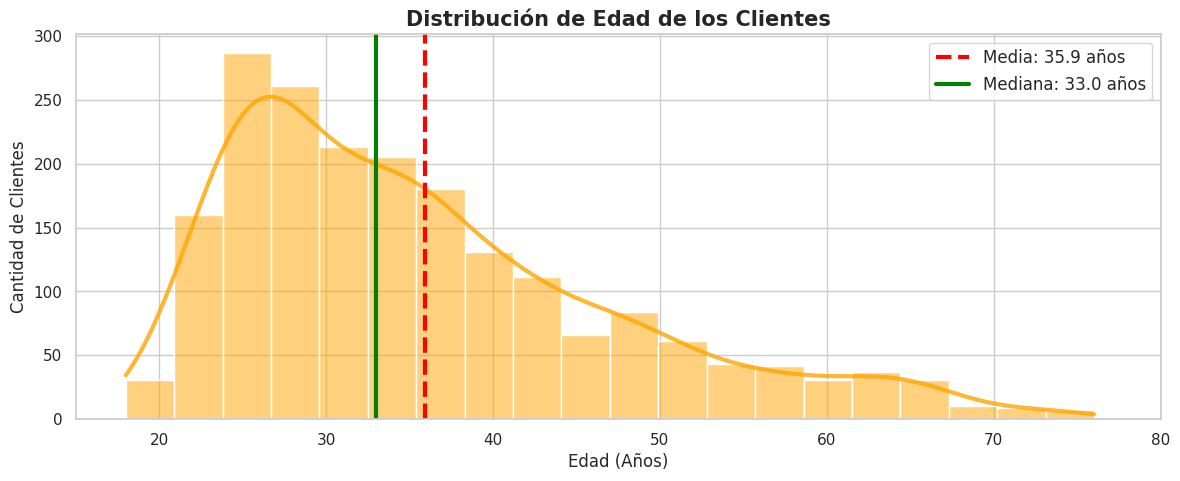

In [52]:
# 1. Cálculos Estadísticos
# Calculamos el promedio aritmético (sensible a valores extremos)
media_edad = clientes["Age"].mean()
# Calculamos el valor central (el "corazón" de los datos, no le afectan los extremos)
mediana_edad = clientes["Age"].median()

# 2. Reporte en texto
print("--- ANÁLISIS DEMOGRÁFICO DE CLIENTES ---")
print(f"Edad Media: {media_edad:.1f} años")
print(f"Edad Mediana: {mediana_edad:.1f} años")

# 3. Configuración del lienzo (tamaño del gráfico)
plt.figure(figsize=(14, 5))

# 4. Creación del Histograma
# 'bins=20' divide las edades en 20 barras
# 'kde=True' dibuja la línea de densidad (la curva suave)
# 'line_kws' personaliza el estilo de esa curva suave
sns.histplot(clientes["Age"], bins=20, color="orange", kde=True,
             line_kws={"linewidth": 3, "color": "darkred", "alpha": 0.8})

# 5. Dibujo de líneas de referencia vertical (axvline)
# Línea roja discontinua para la Media
plt.axvline(media_edad, color="red", linestyle="dashed", linewidth=3,
            label=f"Media: {media_edad:.1f} años")

# Línea verde sólida para la Mediana
plt.axvline(mediana_edad, color="green", linestyle="solid", linewidth=3,
            label=f"Mediana: {mediana_edad:.1f} años")

# 6. Personalización de etiquetas y títulos
plt.title("Distribución de Edad de los Clientes", fontsize=15, fontweight="bold")
plt.xlabel("Edad (Años)")
plt.ylabel("Cantidad de Clientes")

# Ajustamos el rango del eje X para que se vea limpio
plt.xlim(15, 80)

# Mostramos la leyenda para saber qué color es cada línea
plt.legend(fontsize=12)

# Renderizamos el gráfico final
plt.show()

In [58]:
# --- COMPARAMOS LA VARIABILIDAD DE INGRESOS POR EDAD ---

# 1. Agrupamos por Edad y calculamos Media y Desviación Estándar
# La desviación estándar (std) nos dice qué tanto varían los ingresos en esa edad
educ_stats = clientes.groupby("Age")["Income"].agg(["mean", "std"]).round(2)

# 2. Renombramos correctamente para evitar confusiones
# 'std' representa la dispersión o riesgo, no el valor mínimo.
educ_stats.columns = ["Media_Ingresos", "Desviacion_Estandar"]

# 3. Mostramos la tabla de resultados
display(educ_stats)

,Media_Ingresos,Desviacion_Estandar
Age,,
18,99219.00,1603.60
19,100463.00,7133.46
20,106903.17,21077.12
21,106278.15,35761.96
22,103871.76,22714.46
23,105143.66,33130.95
24,103256.60,32943.53
25,105350.44,31153.94
26,105820.80,28468.00


/tmp/ipykernel_152/3383594461.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Occupation", y="Age", data=clientes,


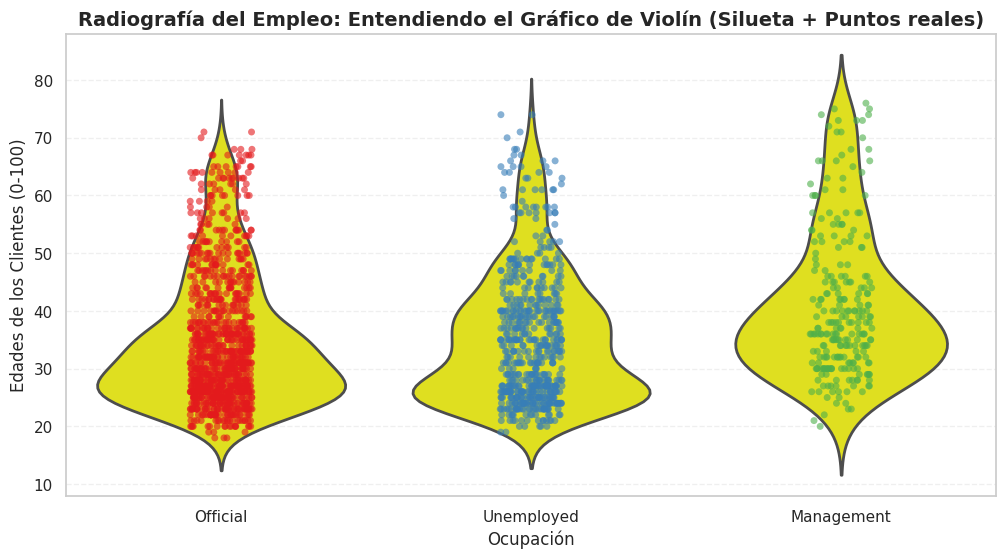

In [59]:
# --- VISUALIZACIÓN DIDÁCTICA: EL VIOLÍN REVELADO ---
plt.figure(figsize=(12, 6))

# 1. Dibujamos la "silueta" (Violin Plot)
# 'inner=None' es clave: elimina las barras internas para que los puntos sean los protagonistas.
# El ancho del amarillo representa la densidad: donde es más gordo, hay más clientes.
sns.violinplot(x="Occupation", y="Age", data=clientes,
               color="yellow", inner=None, linewidth=2)

# 2. Superponemos los datos reales (Strip Plot)
# 'alpha=0.6' permite ver la densidad por superposición (zonas más oscuras).
# 'jitter=True' evita que los puntos se alineen en una sola fila vertical, facilitando la lectura.
# 'palette="Set1"' diferencia visualmente cada categoría de ocupación.
sns.stripplot(x="Occupation", y="Age", data=clientes,
              alpha=0.6, jitter=True, palette="Set1")

# 3. Personalización del gráfico
plt.title("Radiografía del Empleo: Entendiendo el Gráfico de Violín (Silueta + Puntos reales)",
          fontsize=14, fontweight='bold')
plt.ylabel("Edades de los Clientes (0-100)")
plt.xlabel("Ocupación")

# Añadimos una cuadrícula sutil para ayudar a identificar las edades exactas
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()